# Chapter 18: Polars Internals

In [1]:
import polars as pl
pl.__version__  # The book is built with Polars version 1.20.0

'1.32.3'

## Polars' Architecture

### LazyFrame Scan-Level Optimizations

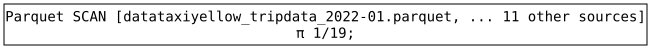

In [2]:
taxis = pl.scan_parquet("data/taxi/yellow_tripdata_*.parquet")
taxis.select(pl.col("trip_distance")).show_graph()

- **π (pi)**: En el contexto de `.show_graph()`, π no se refiere al número matemático, sino que es un símbolo utilizado en los grafos de optimización de Polars para representar una operación de proyección (selección de columnas).

- **σ (sigma)**: El símbolo σ representa una operación de selección o filtrado de filas en el grafo de optimización. Indica que se está aplicando una condición para elegir ciertas filas del DataFrame.

En resumen, en los grafos que muestra `.show_graph()`, π y σ son notaciones estándar de álgebra relacional para indicar proyección (selección de columnas) y selección (filtrado de filas), respectivamente.

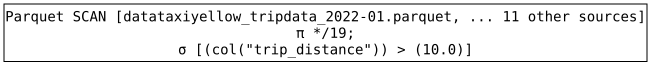

In [3]:
taxis.filter(pl.col("trip_distance") > 10).show_graph()

In [4]:
taxis.head(2).collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
i64,datetime[ns],datetime[ns],f64,f64,f64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,2022-01-01 00:35:40,2022-01-01 00:53:29,2.0,3.8,1.0,"""N""",142,236,1,14.5,3.0,0.5,3.65,0.0,0.3,21.95,2.5,0.0
1,2022-01-01 00:33:43,2022-01-01 00:42:07,1.0,2.1,1.0,"""N""",236,42,1,8.0,0.5,0.5,4.0,0.0,0.3,13.3,0.0,0.0


## Other optimizations

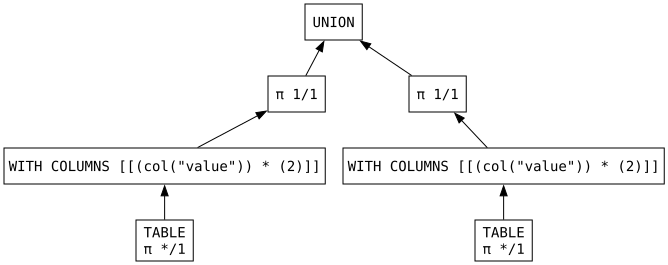

In [5]:
values = pl.LazyFrame({"value": [10, 20, 30, 40, 50, 60]})

common_subplan = values.with_columns(pl.col("value") * 2)

branch1 = common_subplan.select(value2=pl.col("value") * 4)
branch2 = common_subplan.select(value3=pl.col("value") * 2)

combined = pl.concat([branch1, branch2])

combined.show_graph(optimized=False)

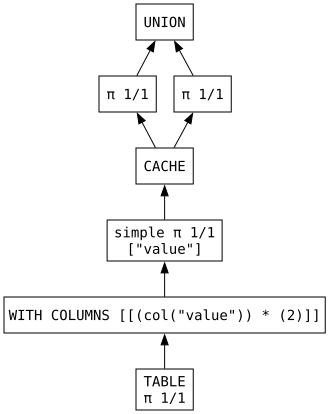

In [6]:
combined.show_graph()

In [7]:
bmi = pl.LazyFrame(
    {"weight_kg": [70, 80, 60, 90], "length_cm": [175, 180, 160, 190]}
)

bmi = (
    bmi.with_columns(weight_per_cm=pl.col("weight_kg") / pl.col("length_cm"))
    .with_columns(weight_kg_average=pl.lit(0))
    .with_columns(length_m=pl.col("length_cm") / 100)
    .with_columns(weight_kg_average=pl.col("weight_kg").mean())
)

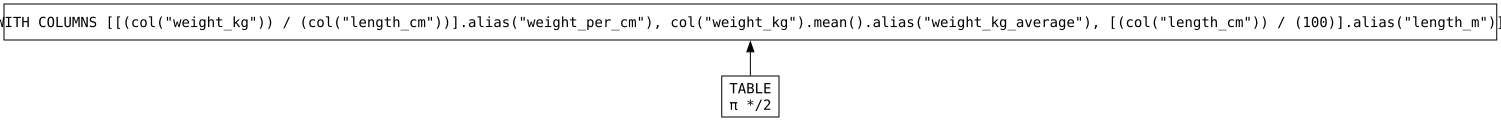

In [8]:
bmi.show_graph()

## Checking Your Expressions

### Descripción general del espacio de nombres Meta

| Método                           | Descripción                                                                                      |
|-----------------------------------|--------------------------------------------------------------------------------------------------|
| `expr.meta.eq`                   | Verifica si dos expresiones son iguales.                                                         |
| `expr.meta.has_multiple_outputs`  | Devuelve `True` si la expresión produce múltiples columnas de salida.                            |
| `expr.meta.is_column`             | Devuelve `True` si la expresión se refiere a una sola columna.                                   |
| `expr.meta.is_column_selection`   | Devuelve `True` si la expresión es una selección de columnas (por ejemplo, una lista de columnas).|
| `expr.meta.is_literal`            | Devuelve `True` si la expresión es un valor literal (no una columna ni un cálculo).              |
| `expr.meta.isregex_projection`    | Devuelve `True` si la expresión selecciona columnas usando una expresión regular.                 |
| `expr.meta.ne`                   | Verifica si dos expresiones no son iguales.                                                      |
| `expr.meta.output_name`           | Devuelve el nombre de la columna de salida de la expresión.                                      |
| `expr.meta.pop`                   | Elimina y devuelve la última expresión de una lista de expresiones.                              |
| `expr.meta.root_names`            | Devuelve una lista con los nombres de las columnas raíz utilizadas en la expresión.               |
| `expr.meta.serialize`             | Serializa la expresión a un formato binario o de texto.                                          |
| `expr.meta.show_graph`            | Muestra el grafo de la expresión para visualizar su estructura.                                  |
| `expr.meta.tree_format`           | Devuelve una representación en árbol de la expresión.                                            |
| `expr.meta.undo_aliases`          | Elimina los alias de la expresión y devuelve la expresión original.                              |
| `expr.meta.write_json`            | Escribe la expresión en formato JSON.                                                            |

Examples

In [9]:
expr1 = pl.col("name")
expr2 = pl.lit("constant")

print(f"Is {expr1} a column: {expr1.meta.is_column()}")
print(f"Is {expr2} a column: {expr2.meta.is_column()}")

Is col("name") a column: True
Is "constant" a column: False


In [10]:
print(f"Is {expr1} a column: {expr1.meta.is_literal()}")
print(f"Is {expr2} a column: {expr2.meta.is_literal()}")

Is col("name") a column: False
Is "constant" a column: True


In [11]:
import polars as pl

def add_or_multiply(df, expr, value):
    # Si value es literal, lo usamos directamente; si es columna, operamos columna a columna
    if value.meta.is_literal():
        return df.with_columns(result=expr + value)
    elif value.meta.is_column():
        return df.with_columns(result=expr * value)
    else:
        raise ValueError("value debe ser columna o literal")

df = pl.DataFrame({"a": [1, 2, 3], "b": [10, 20, 30]})

# Suma 100 a la columna 'a'
print(add_or_multiply(df, pl.col("a"), pl.lit(100)))

# Multiplica 'a' por 'b'
print(add_or_multiply(df, pl.col("a"), pl.col("b")))

shape: (3, 3)
┌─────┬─────┬────────┐
│ a   ┆ b   ┆ result │
│ --- ┆ --- ┆ ---    │
│ i64 ┆ i64 ┆ i64    │
╞═════╪═════╪════════╡
│ 1   ┆ 10  ┆ 101    │
│ 2   ┆ 20  ┆ 102    │
│ 3   ┆ 30  ┆ 103    │
└─────┴─────┴────────┘
shape: (3, 3)
┌─────┬─────┬────────┐
│ a   ┆ b   ┆ result │
│ --- ┆ --- ┆ ---    │
│ i64 ┆ i64 ┆ i64    │
╞═════╪═════╪════════╡
│ 1   ┆ 10  ┆ 10     │
│ 2   ┆ 20  ┆ 40     │
│ 3   ┆ 30  ┆ 90     │
└─────┴─────┴────────┘


In [12]:
expr1 = pl.col("age") * 2
expr2 = pl.col("name").alias("username")

In [13]:
print(f"{expr1} output name: {expr1.meta.output_name()}")
print(f"{expr2} output name: {expr2.meta.output_name()}")

[(col("age")) * (dyn int: 2)] output name: age
col("name").alias("username") output name: username


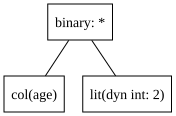

In [14]:
expr = (pl.col("age") * 2).alias("double_age")

expr.meta.show_graph()

In [15]:
expr = pl.col("original_name").alias("new_name")

original_expr = expr.meta.undo_aliases()

original_expr.meta.output_name()  # Debería devolver "original_name"

'original_name'

In [16]:
expr = pl.col("origin").alias("destination")

expr.meta.root_names()  # Debería devolver ["origin"]

['origin']

## Profiling Polars

La función `lf.profile()` en Polars permite obtener un resumen detallado del plan de ejecución de un `LazyFrame`. Este método muestra información sobre el tiempo estimado de cada operación, el número de filas procesadas y el uso de memoria, ayudando a identificar cuellos de botella y optimizar consultas. Es especialmente útil para analizar y depurar pipelines complejos antes de ejecutar `.collect()`. 

**Ejemplo de uso:**

```python
bmi.profile()
```

Esto generará un reporte con estadísticas de cada etapa del pipeline lazy.

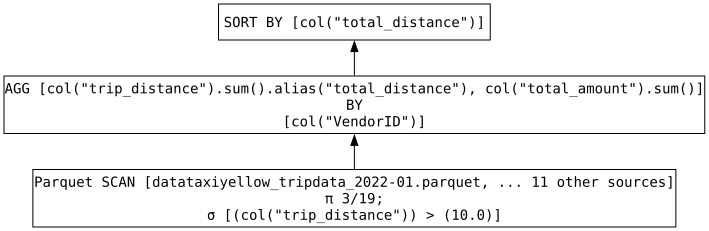

In [17]:
long_distance_taxis_per_vendor_sorted = (
    pl.scan_parquet("data/taxi/yellow_tripdata_*.parquet")
    .filter(pl.col("trip_distance") > 10)
    .select(pl.col("VendorID"), pl.col("trip_distance"), pl.col("total_amount"))
    .group_by("VendorID")
    .agg(
        total_distance=pl.col("trip_distance").sum(),
        total_amount=pl.col("total_amount").sum(),
    )
    .sort("total_distance", descending=True)
)

long_distance_taxis_per_vendor_sorted.show_graph()

In [18]:
result, profiling_info = long_distance_taxis_per_vendor_sorted.profile()

In [19]:
result

VendorID,total_distance,total_amount
i64,f64,f64
2,1.3752e8,1.6152e8
1,1.3095e7,5.2274e7
6,347579.41,1.3881e6
5,1956.44,8702.21


In [20]:
profiling_info

node,start,end
str,u64,u64
"""optimization""",0,504954
"""group_by_partitioned(VendorID)""",504954,631451
"""sort(total_distance)""",631493,635034


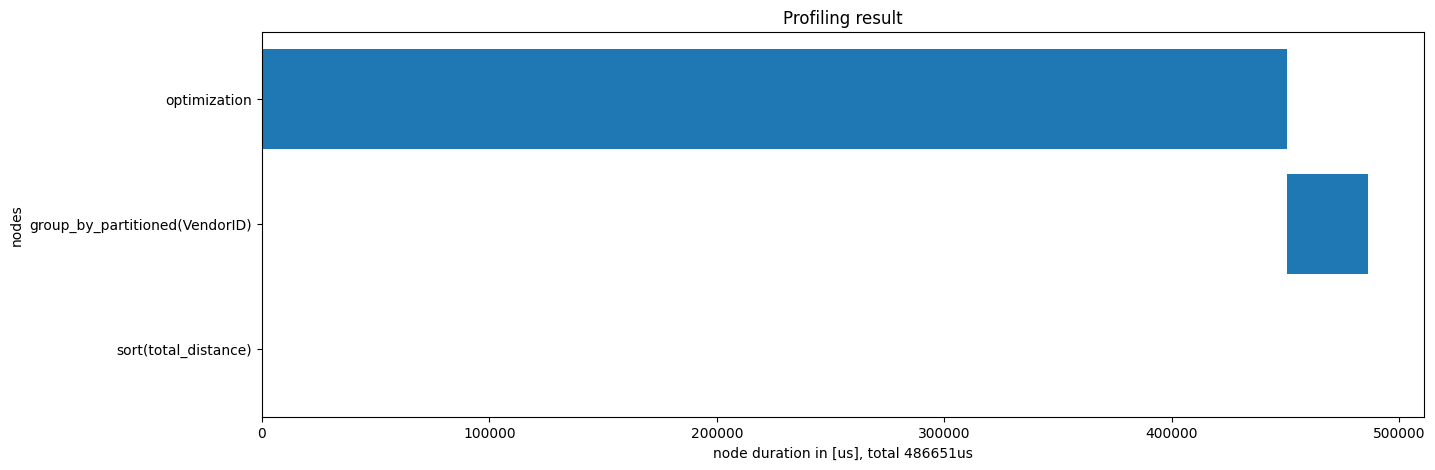

(shape: (4, 3)
 ┌──────────┬────────────────┬──────────────┐
 │ VendorID ┆ total_distance ┆ total_amount │
 │ ---      ┆ ---            ┆ ---          │
 │ i64      ┆ f64            ┆ f64          │
 ╞══════════╪════════════════╪══════════════╡
 │ 2        ┆ 1.3752e8       ┆ 1.6152e8     │
 │ 1        ┆ 1.3095e7       ┆ 5.2274e7     │
 │ 6        ┆ 347579.41      ┆ 1.3881e6     │
 │ 5        ┆ 1956.44        ┆ 8702.21      │
 └──────────┴────────────────┴──────────────┘,
 shape: (3, 3)
 ┌────────────────────────────────┬────────┬────────┐
 │ node                           ┆ start  ┆ end    │
 │ ---                            ┆ ---    ┆ ---    │
 │ str                            ┆ u64    ┆ u64    │
 ╞════════════════════════════════╪════════╪════════╡
 │ optimization                   ┆ 0      ┆ 450393 │
 │ group_by_partitioned(VendorID) ┆ 450393 ┆ 486401 │
 │ sort(total_distance)           ┆ 486415 ┆ 486651 │
 └────────────────────────────────┴────────┴────────┘)

In [21]:
long_distance_taxis_per_vendor_sorted.profile(show_plot=True, figsize=(15, 5))

## Test in Polars

### Comparing DataFrames and Series

In [22]:
from polars.testing import (
    assert_series_equal,
    assert_frame_equal,
    assert_series_not_equal,
    assert_frame_not_equal,
)

In [23]:
floats = pl.DataFrame({"a": [1.0, 2.0, 3.0, 4.0]})

different_floats = pl.DataFrame({"a": [1.001, 2.0, 3.0, 4.0]})

In [24]:
# This raises an AssertionError:
# assert_frame_equal(floats, different_floats)

In [25]:
assert_frame_equal(floats, different_floats, rel_tol=0.01)
print("The DataFrames are equal.")

The DataFrames are equal.


| Argument              | Description                                                                                   |
|-----------------------|-----------------------------------------------------------------------------------------------|
| `check_row_order`     | If `True`, the order of rows must match exactly between the compared objects.                 |
| `check_column_order`  | If `True`, the order of columns must match exactly between the compared objects.              |
| `check_dtypes`        | If `True`, data types of columns must match exactly.                                          |
| `check_exact`         | If `True`, values must match exactly; if `False`, allows for tolerance-based comparison.      |
| `rtol`                | Relative tolerance for comparing floating point values (used if `check_exact=False`).         |
| `atol`                | Absolute tolerance for comparing floating point values (used if `check_exact=False`).         |
| `categorical_as_str`  | If `True`, compares categorical columns as strings instead of their underlying codes.         |

In [26]:
result = pl.DataFrame({"a": [1, 3], "b": [2, 4]}).cast(
    pl.Schema({"a": pl.Int8, "b": pl.Int8})
)

expected = pl.from_repr(
    """
┌─────┬─────┐
│ a   ┆ b   │
│ --- ┆ --- │
│ i8  ┆ i8  │
╞═════╪═════╡
│ 1   ┆ 2   │
│ 3   ┆ 4   │
└─────┴─────┘
    """
)

assert_frame_equal(result, expected)
print("DataFrames are equal")

DataFrames are equal


## Common Antipatterns

### Using Brackets for Column Selection

### Misusing Collect

In [27]:
%%time
taxis = pl.scan_parquet("data/taxi/yellow_tripdata_*.parquet")
vendor0 = taxis.filter(pl.col("VendorID") == 0).collect()
vendor1 = taxis.filter(pl.col("VendorID") == 1).collect()

CPU times: total: 23.9 s
Wall time: 3.31 s


In [28]:
%%time
taxis = pl.scan_parquet("data/taxi/yellow_tripdata_*.parquet")
vendors = taxis.filter(pl.col("VendorID").is_in([0, 1])).collect()
vendor0 = vendors.filter(pl.col("VendorID") == 0)
vendor1 = vendors.filter(pl.col("VendorID") == 1)

CPU times: total: 38.9 s
Wall time: 8.83 s
